In [1]:
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# statistics (optional but useful)
import scipy as sp
from scipy import stats

In [2]:
import chardet

with open('data_source/bikeshare-ridership-2025/bikeshare_2025_01.csv', 'rb') as f:
    result = chardet.detect(f.read(100000))
    print(result)

{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


In [3]:
df_jan_25 = pd.read_csv('data_source/bikeshare-ridership-2025/bikeshare_2025_01.csv', 
                          encoding='cp1252')
df_jan_25.head()
df_jan_25.shape
df_jan_25.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202946 entries, 0 to 202945
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Trip_Id             202946 non-null  int64  
 1   Trip_Duration       202946 non-null  int64  
 2   Start_Station_Id    202946 non-null  int64  
 3   Start_Time          202946 non-null  object 
 4   Start_Station_Name  202946 non-null  object 
 5   End_Station_Id      202811 non-null  float64
 6   End_Time            202920 non-null  object 
 7   End_Station_Name    202946 non-null  object 
 8   Bike_Id             202946 non-null  int64  
 9   User_Type           202946 non-null  object 
 10  Bike_Model          202946 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 17.0+ MB


In [4]:
df_jan_25['User_Type'].unique()


array(['Member', 'Casual'], dtype=object)

In [5]:
df_jan_25['Bike_Model'].unique()

array(['ICONIC', 'EFIT G5', 'EFIT'], dtype=object)

In [6]:
import glob

path = 'data_source/bikeshare-ridership-2025/'
files = sorted(glob.glob(path + 'bikeshare_2025_*.csv'))

print(len(files))  # confirm 12 months found

12


In [7]:
for f in files:
    temp = pd.read_csv(f, encoding='cp1252', nrows=5)  # just read 5 rows, fast check
    print(f, '->', list(temp.columns))

data_source/bikeshare-ridership-2025/bikeshare_2025_01.csv -> ['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time', 'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name', 'Bike_Id', 'User_Type', 'Bike_Model']
data_source/bikeshare-ridership-2025/bikeshare_2025_02.csv -> ['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time', 'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name', 'Bike_Id', 'User_Type', 'Bike_Model']
data_source/bikeshare-ridership-2025/bikeshare_2025_03.csv -> ['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time', 'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name', 'Bike_Id', 'User_Type', 'Bike_Model']
data_source/bikeshare-ridership-2025/bikeshare_2025_04.csv -> ['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time', 'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name', 'Bike_Id', 'User_Type', 'Bike_Model']
data_source/bikeshare-ridership-2025/bikeshare_2025_05.csv -

In [8]:
df_2025 = [pd.read_csv(f, encoding='cp1252') for f in files]
df_25 = pd.concat(df_2025, ignore_index=True)

print(df_25.shape)
df_25.info()

(7812520, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7812520 entries, 0 to 7812519
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Trip_Id             int64  
 1   Trip_Duration       int64  
 2   Start_Station_Id    float64
 3   Start_Time          object 
 4   Start_Station_Name  object 
 5   End_Station_Id      float64
 6   End_Time            object 
 7   End_Station_Name    object 
 8   Bike_Id             int64  
 9   User_Type           object 
 10  Bike_Model          object 
dtypes: float64(2), int64(3), object(6)
memory usage: 655.7+ MB


In [9]:
df_25['Start_Station_Id'].isna().sum()

7

In [10]:
df_25['End_Station_Id'].isna().sum()

6761

In [11]:
df_25['End_Time'].isna().sum()

1092

In [12]:
df_25.isna().sum()


Trip_Id                  0
Trip_Duration            0
Start_Station_Id         7
Start_Time               0
Start_Station_Name       7
End_Station_Id        6761
End_Time              1092
End_Station_Name       924
Bike_Id                  0
User_Type                0
Bike_Model               0
dtype: int64

In [13]:
df_25.duplicated().sum()

0

In [14]:
df_25['Trip_Id'].duplicated().sum()  # Trip_Id should be unique

0

In [15]:
df_25[df_25['Start_Station_Id'].isna()]

,Trip_Id,Trip_Duration,Start_Station_Id,Start_Time,Start_Station_Name,End_Station_Id,End_Time,End_Station_Name,Bike_Id,User_Type,Bike_Model
5409066,40954646,40,NaN,2025-09-08 13:46:28,NaN,NaN,2025-09-08 13:47:08,NaN,10618,Member,ICONIC
5409646,40956135,11,NaN,2025-09-08 14:37:50,NaN,NaN,2025-09-08 14:38:01,NaN,10618,Member,ICONIC
5409997,40956146,5,NaN,2025-09-08 14:38:09,NaN,NaN,2025-09-08 14:38:14,NaN,10618,Member,ICONIC
5410513,40956155,77,NaN,2025-09-08 14:38:23,NaN,NaN,2025-09-08 14:39:40,NaN,10618,Member,ICONIC
5507074,41065430,17,NaN,2025-09-10 22:43:28,NaN,NaN,2025-09-10 22:43:45,NaN,8534,Member,EFIT
5507462,41065464,6,NaN,2025-09-10 22:44:52,NaN,NaN,2025-09-10 22:44:58,NaN,8534,Member,EFIT
5924410,41541544,14,NaN,2025-09-22 16:32:42,NaN,NaN,2025-09-22 16:32:56,NaN,10618,Member,ICONIC


In [16]:
df_25[df_25['End_Station_Id'].isna()].head(10)


,Trip_Id,Trip_Duration,Start_Station_Id,Start_Time,Start_Station_Name,End_Station_Id,End_Time,End_Station_Name,Bike_Id,User_Type,Bike_Model
190,34637838,1138,7432.0,2025-01-01 00:47:02,Frederick St / King St E,NaN,2025-01-01 01:06:00,Frederick St / King St E,212,Casual,ICONIC
692,34638383,0,7770.0,2025-01-01 03:47:06,Spadina Ave / Sullivan St,NaN,NaN,Spadina Ave / Sullivan St,2212,Casual,ICONIC
1325,34639326,0,7660.0,2025-01-01 12:13:38,285 Victoria St,NaN,2025-01-01 12:13:38,285 Victoria St,2249,Member,ICONIC
2264,34640716,0,7043.0,2025-01-01 16:13:01,Queens Quay W / Lower Simcoe St,NaN,NaN,Queens Quay W / Lower Simcoe St,646,Casual,ICONIC
2914,34641136,0,7416.0,2025-01-01 17:14:21,Spadina Ave / Blue Jays Way,NaN,2025-01-01 17:14:21,Spadina Ave / Blue Jays Way,4764,Casual,ICONIC
3279,34641638,0,7164.0,2025-01-01 18:39:58,Gould St / Yonge St (TMU),NaN,NaN,Gould St / Yonge St (TMU),189,Member,ICONIC
3828,34642124,0,7037.0,2025-01-01 20:46:28,Bathurst St / Dundas St W,NaN,NaN,Bathurst St / Dundas St W,4157,Member,ICONIC
6465,34645747,0,7239.0,2025-01-02 12:42:49,Bloor St W / Manning Ave - SMART,NaN,2025-01-02 12:42:49,Bloor St W / Manning Ave - SMART,795,Member,ICONIC
10945,34650796,0,7272.0,2025-01-03 00:34:09,Yonge St / Dundonald St,NaN,2025-01-03 00:34:09,Yonge St / Dundonald St,407,Member,ICONIC
15280,34655689,0,7235.0,2025-01-03 16:09:32,Bay St / College St (West Side) - SMART,NaN,2025-01-03 16:09:32,Bay St / College St (West Side) - SMART,7322,Member,ICONIC


In [17]:
# check trip duration distribution for rows with null End_Station_Id
df_25[df_25['End_Station_Id'].isna()]['Trip_Duration'].describe()

count      6761.000000
mean       1855.545777
std        8536.544932
min           0.000000
25%           0.000000
50%         351.000000
75%        1142.000000
max      151037.000000
Name: Trip_Duration, dtype: float64

In [18]:
df_25[df_25['End_Station_Id'].isna()]['Bike_Model'].value_counts()

Bike_Model
ICONIC     5432
EFIT        957
EFIT G5     372
Name: count, dtype: int64

In [19]:
null_rows = df_25[df_25['End_Station_Id'].isna()]
(null_rows['Start_Station_Name'] == null_rows['End_Station_Name']).value_counts()

True     5837
False     924
Name: count, dtype: int64

In [20]:
zero_duration = df_25[(df_25['End_Station_Id'].isna()) & (df_25['Trip_Duration'] == 0)]
print(f"Zero duration nulls: {len(zero_duration)}")

normal_duration = df_25[(df_25['End_Station_Id'].isna()) & (df_25['Trip_Duration'] > 0)]
print(f"Non-zero duration nulls: {len(normal_duration)}")

Zero duration nulls: 2986
Non-zero duration nulls: 3775


In [21]:
normal_duration['End_Time'].isna().sum()

0

In [22]:
# Document the pattern found, but don't modify data yet
zero_duration_nulls = ((df_25['Trip_Duration'] == 0) & (df_25['End_Station_Id'].isna())).sum()
print(f"Zero-duration failed trips: {zero_duration_nulls}")

Zero-duration failed trips: 2986


In [23]:
real_trips_missing_end = ((df_25['Trip_Duration'] > 0) & (df_25['End_Station_Id'].isna())).sum()
print(f"Real trips missing End_Station_Id: {real_trips_missing_end}")


Real trips missing End_Station_Id: 3775


In [24]:
df_25.describe()
df_25['User_Type'].value_counts()
df_25['Bike_Model'].value_counts()

Bike_Model
ICONIC     6298758
EFIT       1024014
EFIT G5     489748
Name: count, dtype: int64

In [25]:
import chardet

with open('data_source/bikeshare-ridership-2024.csv', 'rb') as f:
    result = chardet.detect(f.read(100000))
    print(result)

{'encoding': 'ascii', 'confidence': 1.0, 'language': ''}


In [26]:
df_24 = pd.read_csv('data_source/bikeshare-ridership-2024.csv')

df_24.shape
df_24.info()
df_24.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6953094 entries, 0 to 6953093
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Trip_Id             int64  
 1   Trip_Duration       int64  
 2   Start_Station_Id    int64  
 3   Start_Time          object 
 4   Start_Station_Name  object 
 5   End_Station_Id      float64
 6   End_Time            object 
 7   End_Station_Name    object 
 8   Bike_Id             int64  
 9   User_Type           object 
 10  Bike_Model          object 
dtypes: float64(1), int64(4), object(6)
memory usage: 583.5+ MB


,Trip_Id,Trip_Duration,Start_Station_Id,Start_Time,Start_Station_Name,End_Station_Id,End_Time,End_Station_Name,Bike_Id,User_Type,Bike_Model
0,26682740,528,7041,2024-01-01 00:00:08,Edward St / Yonge St,7130.0,2024-01-01 00:08:56,Davenport Rd / Bedford Rd,7855,Casual,EFIT G5
1,26682742,1924,7245,2024-01-01 00:02:04,Tecumseth St / Queen St W - SMART,7259.0,2024-01-01 00:34:08,Lower Spadina Ave / Lake Shore Blvd W,2453,Casual,ICONIC
2,26682743,2741,7052,2024-01-01 00:03:25,Wellington St W / Bay St,7366.0,2024-01-01 00:49:06,Fort York Blvd / Bathurst St - SMART,7332,Member,ICONIC
3,26682744,353,7041,2024-01-01 00:03:39,Edward St / Yonge St,7418.0,2024-01-01 00:09:32,College Park - Yonge St Entrance,782,Member,ICONIC
4,26682746,2118,7721,2024-01-01 00:04:44,Widmer St / King St W,7721.0,2024-01-01 00:40:02,Widmer St / King St W,1008,Member,ICONIC


In [27]:
print(list(df_24.columns))
print(list(df_25.columns))

set(df_24.columns) == set(df_25.columns)

['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time', 'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name', 'Bike_Id', 'User_Type', 'Bike_Model']
['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time', 'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name', 'Bike_Id', 'User_Type', 'Bike_Model']


True

In [28]:
df_24.isna().sum()

Trip_Id                  0
Trip_Duration            0
Start_Station_Id         0
Start_Time               0
Start_Station_Name       0
End_Station_Id        8424
End_Time              5822
End_Station_Name      8424
Bike_Id                  0
User_Type                0
Bike_Model               0
dtype: int64

In [29]:
df_24.duplicated().sum()
df_24['Trip_Id'].duplicated().sum()

0

In [30]:
zero_duration_24 = ((df_24['Trip_Duration'] == 0) & (df_24['End_Station_Id'].isna())).sum()
print(f"Zero-duration failed trips (2024): {zero_duration_24}")

real_trips_missing_end_24 = ((df_24['Trip_Duration'] > 0) & (df_24['End_Station_Id'].isna())).sum()
print(f"Real trips missing End_Station_Id (2024): {real_trips_missing_end_24}")

Zero-duration failed trips (2024): 5044
Real trips missing End_Station_Id (2024): 3380


In [31]:
df_24['Year'] = 2024
df_25['Year'] = 2025

df_all = pd.concat([df_24, df_25], ignore_index=True)

print(df_all.shape)  # should be ~14,765,614
df_all.info()

(14765614, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14765614 entries, 0 to 14765613
Data columns (total 12 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Trip_Id             int64  
 1   Trip_Duration       int64  
 2   Start_Station_Id    float64
 3   Start_Time          object 
 4   Start_Station_Name  object 
 5   End_Station_Id      float64
 6   End_Time            object 
 7   End_Station_Name    object 
 8   Bike_Id             int64  
 9   User_Type           object 
 10  Bike_Model          object 
 11  Year                int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 1.3+ GB


In [32]:
df_all['Trip_Id'] = pd.to_numeric(df_all['Trip_Id'], downcast='integer')
df_all['Trip_Duration'] = pd.to_numeric(df_all['Trip_Duration'], downcast='integer')
df_all['Bike_Id'] = pd.to_numeric(df_all['Bike_Id'], downcast='integer')
df_all['Year'] = pd.to_numeric(df_all['Year'], downcast='integer')

In [33]:
df_all['Start_Station_Id'] = pd.to_numeric(df_all['Start_Station_Id'], downcast='float')
df_all['End_Station_Id'] = pd.to_numeric(df_all['End_Station_Id'], downcast='float')

In [34]:
df_all['User_Type'] = df_all['User_Type'].astype('category')
df_all['Bike_Model'] = df_all['Bike_Model'].astype('category')
df_all['Start_Station_Name'] = df_all['Start_Station_Name'].astype('category')
df_all['End_Station_Name'] = df_all['End_Station_Name'].astype('category')

In [35]:
df_all['Start_Time'] = pd.to_datetime(df_all['Start_Time'])
df_all['End_Time'] = pd.to_datetime(df_all['End_Time'])

In [36]:
df_all.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14765614 entries, 0 to 14765613
Data columns (total 12 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Trip_Id             int32         
 1   Trip_Duration       int32         
 2   Start_Station_Id    float32       
 3   Start_Time          datetime64[ns]
 4   Start_Station_Name  category      
 5   End_Station_Id      float32       
 6   End_Time            datetime64[ns]
 7   End_Station_Name    category      
 8   Bike_Id             int16         
 9   User_Type           category      
 10  Bike_Model          category      
 11  Year                int16         
dtypes: category(4), datetime64[ns](2), float32(2), int16(2), int32(2)
memory usage: 591.7 MB


In [37]:

df_all['Year'].value_counts()

Year
2025    7812520
2024    6953094
Name: count, dtype: int64

In [38]:
df_all.isna().sum()

Trip_Id                   0
Trip_Duration             0
Start_Station_Id          7
Start_Time                0
Start_Station_Name        7
End_Station_Id        15185
End_Time               6914
End_Station_Name       9348
Bike_Id                   0
User_Type                 0
Bike_Model                0
Year                      0
dtype: int64

In [39]:
df_all.dtypes


Trip_Id                        int32
Trip_Duration                  int32
Start_Station_Id             float32
Start_Time            datetime64[ns]
Start_Station_Name          category
End_Station_Id               float32
End_Time              datetime64[ns]
End_Station_Name            category
Bike_Id                        int16
User_Type                   category
Bike_Model                  category
Year                           int16
dtype: object

In [40]:
df_all['User_Type'].cat.categories
df_all['Bike_Model'].cat.categories

Index(['EFIT', 'EFIT G5', 'ICONIC'], dtype='object')

In [41]:
df_all.memory_usage(deep=True).sort_values(ascending=False) / 1024**2


Start_Time            112.652695
End_Time              112.652695
Trip_Id                56.326347
Trip_Duration          56.326347
Start_Station_Id       56.326347
End_Station_Id         56.326347
End_Station_Name       28.283514
Start_Station_Name     28.283439
Bike_Id                28.163174
Year                   28.163174
Bike_Model             14.081869
User_Type              14.081810
Index                   0.000122
dtype: float64

In [42]:
print(df_all['User_Type'].unique())
print(df_all['Bike_Model'].unique())

['Casual', 'Member']
Categories (2, object): ['Casual', 'Member']
['EFIT G5', 'ICONIC', 'EFIT']
Categories (3, object): ['EFIT', 'EFIT G5', 'ICONIC']


In [43]:
df_all['Trip_Duration'].describe()

count    1.476561e+07
mean     9.671225e+02
std      3.862761e+03
min      0.000000e+00
25%      4.190000e+02
50%      6.760000e+02
75%      1.086000e+03
max      2.487915e+06
Name: Trip_Duration, dtype: float64

In [44]:
# 1. unique values in categorical columns
print(df_all['User_Type'].unique())
print(df_all['Bike_Model'].unique())

['Casual', 'Member']
Categories (2, object): ['Casual', 'Member']
['EFIT G5', 'ICONIC', 'EFIT']
Categories (3, object): ['EFIT', 'EFIT G5', 'ICONIC']


In [45]:
# 2. trip duration outliers
df_all['Trip_Duration'].describe()
(df_all['Trip_Duration'] == 0).sum()
(df_all['Trip_Duration'] > 86400).sum()

879

In [46]:
# 3. date range check
print(df_all['Start_Time'].min())
print(df_all['Start_Time'].max())

2024-01-01 00:00:08
2025-12-31 23:59:49


In [47]:
(df_all['Trip_Duration'] == 0).sum()

16352

In [48]:
df_trips = df_all[df_all['Trip_Duration'] > 0]

✅ 14,765,614 rows — 2 full years
✅ Memory optimized — ~591MB
✅ Dtypes correct
✅ Categorical columns clean
✅ Date range verified — Jan 2024 to Dec 2025
✅ Nulls documented — not dropped
✅ Time features extracted — month, hour, day_of_week, season
✅ Zero duration trips handled — filtered via df_trips
✅ Long trips documented — 879 trips over 24 hours

In [49]:
df_all['month'] = df_all['Start_Time'].dt.month.astype('int8')
df_all['hour'] = df_all['Start_Time'].dt.hour.astype('int8')
df_all['day_of_week'] = df_all['Start_Time'].dt.day_name().astype('category')
df_all['season'] = df_all['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}).astype('category')

# verify
print(df_all.columns.tolist())
df_all[['month', 'hour', 'day_of_week', 'season']].head()

['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time', 'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name', 'Bike_Id', 'User_Type', 'Bike_Model', 'Year', 'month', 'hour', 'day_of_week', 'season']


,month,hour,day_of_week,season
0,1,0,Monday,Winter
1,1,0,Monday,Winter
2,1,0,Monday,Winter
3,1,0,Monday,Winter
4,1,0,Monday,Winter


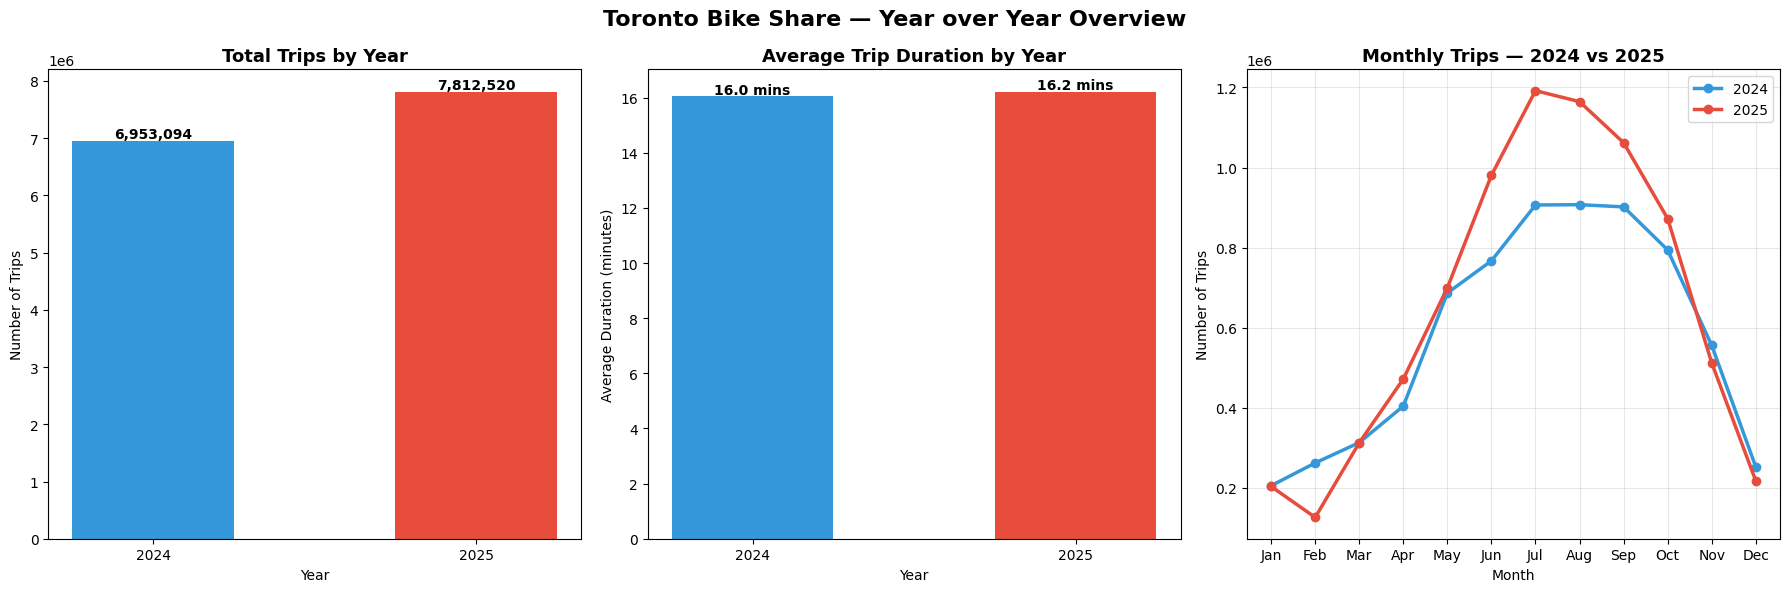

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('visualizations', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── 1. Total trips by year ─────────────────────────────────────
trips_by_year = df_all.groupby('Year').size().reset_index(name='trips')

bars = axes[0].bar(trips_by_year['Year'].astype(str),
                   trips_by_year['trips'],
                   color=['#3498db', '#e74c3c'], width=0.5)
axes[0].set_title('Total Trips by Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Trips')
for bar, val in zip(bars, trips_by_year['trips']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50000,
                 f'{val:,.0f}', ha='center',
                 fontsize=10, fontweight='bold')

# ── 2. Average trip duration by year ──────────────────────────
avg_duration = df_trips.groupby('Year')['Trip_Duration'].mean() / 60  # convert to minutes

bars = axes[1].bar(avg_duration.index.astype(str),
                   avg_duration.values,
                   color=['#3498db', '#e74c3c'], width=0.5)
axes[1].set_title('Average Trip Duration by Year',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Duration (minutes)')
for bar, val in zip(bars, avg_duration.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.1f} mins', ha='center',
                 fontsize=10, fontweight='bold')

# ── 3. Trips by month — 2024 vs 2025 ──────────────────────────
trips_by_month = df_all.groupby(['Year', 'month']).size().reset_index(name='trips')

for year, color in [(2024, '#3498db'), (2025, '#e74c3c')]:
    data = trips_by_month[trips_by_month['Year'] == year]
    axes[2].plot(data['month'], data['trips'],
                 color=color, linewidth=2.5,
                 marker='o', markersize=6,
                 label=str(year))

axes[2].set_title('Monthly Trips — 2024 vs 2025',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Number of Trips')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle('Toronto Bike Share — Year over Year Overview',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/year_over_year.png', dpi=150)
plt.show()

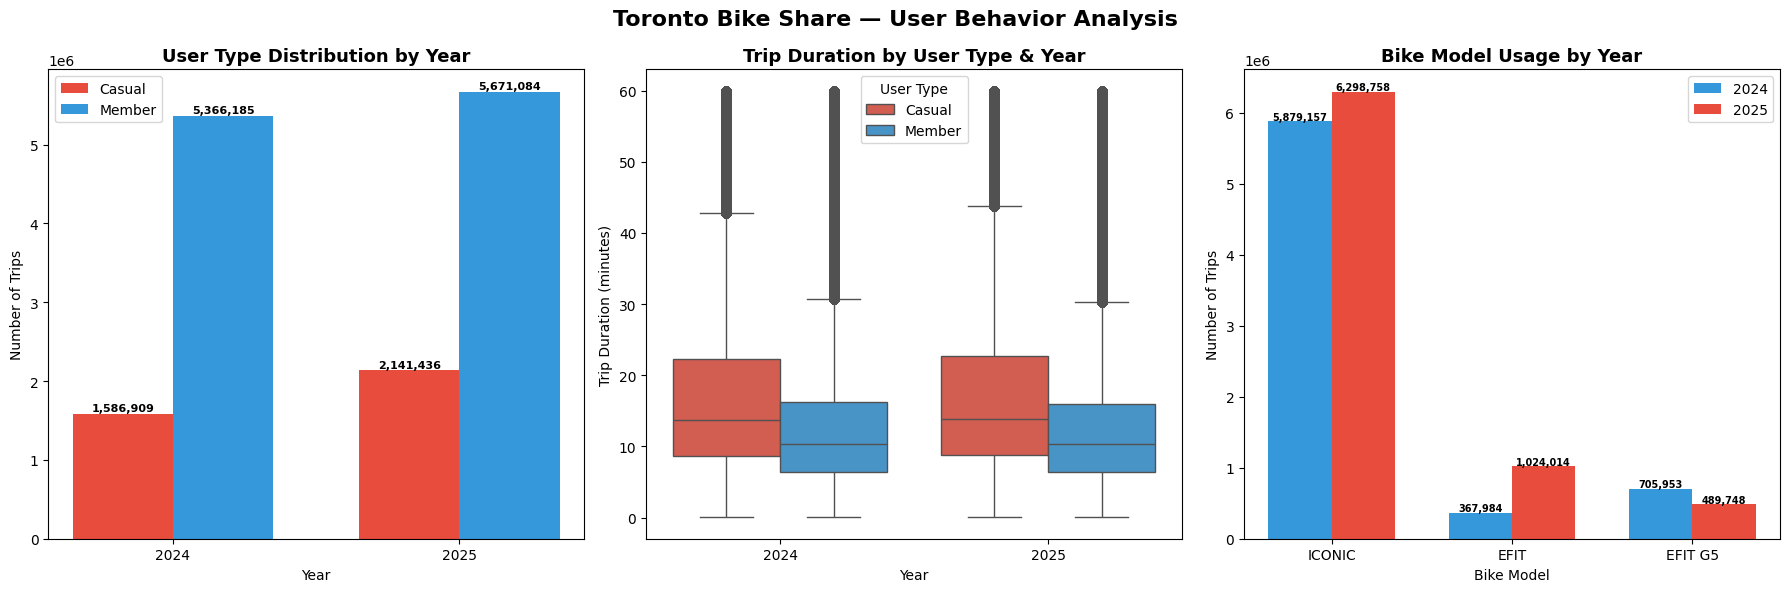

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── 4. User type distribution by year ─────────────────────────
user_year = df_all.groupby(['Year', 'User_Type']).size().reset_index(name='trips')

x = np.arange(2)
width = 0.35

casual_2024 = user_year[(user_year['Year']==2024) & (user_year['User_Type']=='Casual')]['trips'].values[0]
member_2024 = user_year[(user_year['Year']==2024) & (user_year['User_Type']=='Member')]['trips'].values[0]
casual_2025 = user_year[(user_year['Year']==2025) & (user_year['User_Type']=='Casual')]['trips'].values[0]
member_2025 = user_year[(user_year['Year']==2025) & (user_year['User_Type']=='Member')]['trips'].values[0]

bars1 = axes[0].bar(x - width/2, [casual_2024, casual_2025],
                    width, color='#e74c3c', label='Casual')
bars2 = axes[0].bar(x + width/2, [member_2024, member_2025],
                    width, color='#3498db', label='Member')

axes[0].set_title('User Type Distribution by Year',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Trips')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['2024', '2025'])
axes[0].legend()

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30000,
                 f'{bar.get_height():,.0f}',
                 ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30000,
                 f'{bar.get_height():,.0f}',
                 ha='center', fontsize=8, fontweight='bold')

# ── 5. Trip duration by user type (box plot) ──────────────────
# cap at 60 mins for readability
df_plot = df_trips[df_trips['Trip_Duration'] <= 3600].copy()
df_plot['Duration_mins'] = df_plot['Trip_Duration'] / 60

sns.boxplot(data=df_plot, x='Year', y='Duration_mins',
            hue='User_Type',
            palette={'Casual': '#e74c3c', 'Member': '#3498db'},
            ax=axes[1])

axes[1].set_title('Trip Duration by User Type & Year',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Trip Duration (minutes)')
axes[1].legend(title='User Type')

# ── 6. Bike model usage by year ───────────────────────────────
bike_year = df_all.groupby(['Year', 'Bike_Model']).size().reset_index(name='trips')

x = np.arange(3)
width = 0.35
models = ['ICONIC', 'EFIT', 'EFIT G5']

vals_2024 = [bike_year[(bike_year['Year']==2024) & 
             (bike_year['Bike_Model']==m)]['trips'].values[0] 
             for m in models]
vals_2025 = [bike_year[(bike_year['Year']==2025) & 
             (bike_year['Bike_Model']==m)]['trips'].values[0] 
             for m in models]

bars1 = axes[2].bar(x - width/2, vals_2024, width,
                    color='#3498db', label='2024')
bars2 = axes[2].bar(x + width/2, vals_2025, width,
                    color='#e74c3c', label='2025')

axes[2].set_title('Bike Model Usage by Year',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Bike Model')
axes[2].set_ylabel('Number of Trips')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models)
axes[2].legend()

for bar in bars1:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20000,
                 f'{bar.get_height():,.0f}',
                 ha='center', fontsize=7, fontweight='bold')
for bar in bars2:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20000,
                 f'{bar.get_height():,.0f}',
                 ha='center', fontsize=7, fontweight='bold')

fig.suptitle('Toronto Bike Share — User Behavior Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/user_behavior.png', dpi=150)
plt.show()

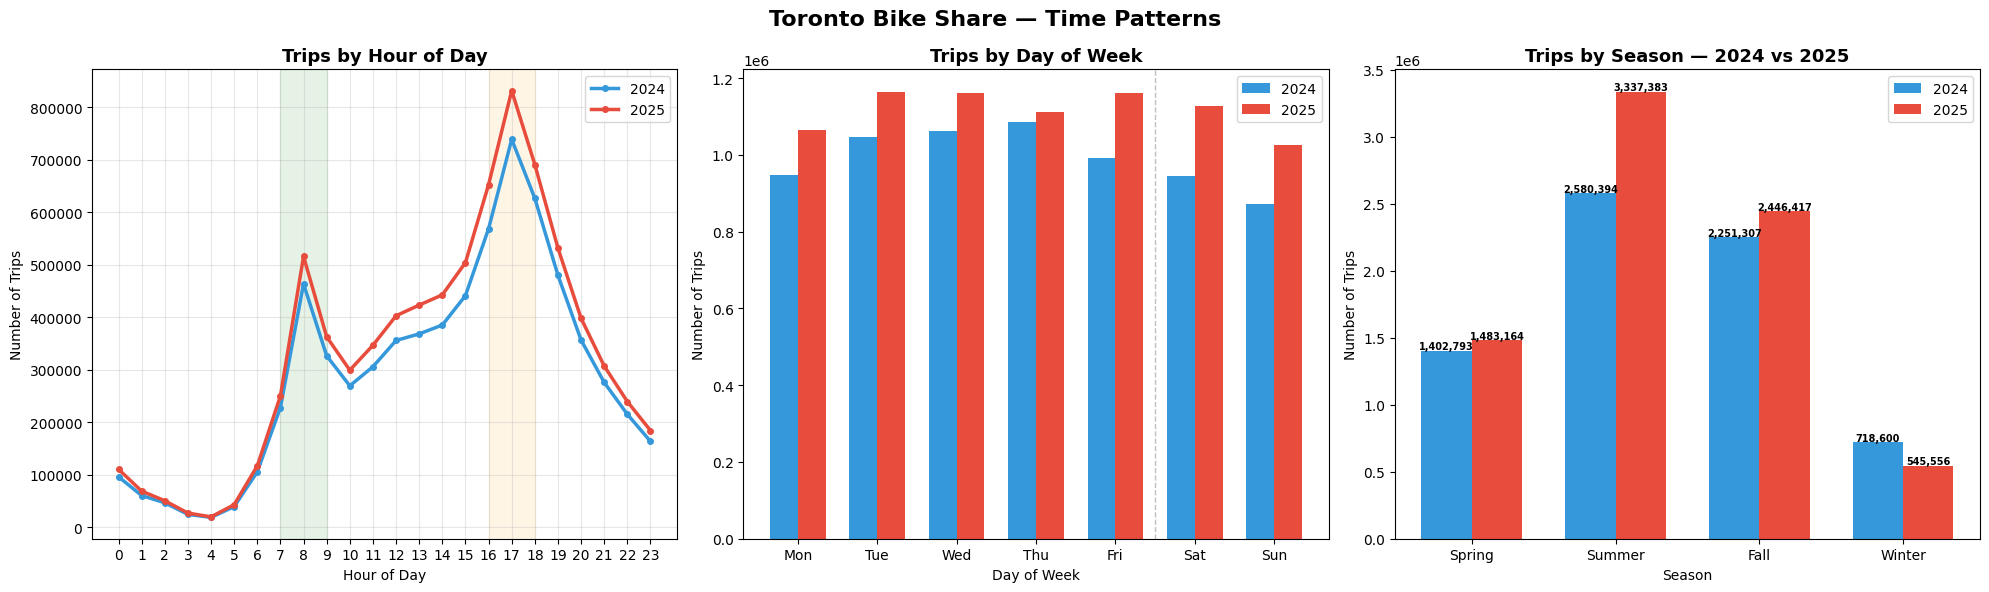

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── 7. Trips by hour of day ────────────────────────────────────
trips_by_hour = df_all.groupby(['hour', 'Year']).size().reset_index(name='trips')

for year, color in [(2024, '#3498db'), (2025, '#e74c3c')]:
    data = trips_by_hour[trips_by_hour['Year'] == year]
    axes[0].plot(data['hour'], data['trips'],
                 color=color, linewidth=2.5,
                 marker='o', markersize=4,
                 label=str(year))

axes[0].set_title('Trips by Hour of Day',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Trips')
axes[0].set_xticks(range(0, 24))
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axvspan(7, 9, alpha=0.1, color='green', label='Morning rush')
axes[0].axvspan(16, 18, alpha=0.1, color='orange', label='Evening rush')

# ── 8. Trips by day of week ────────────────────────────────────
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

trips_by_day = df_all.groupby(['day_of_week', 'Year']).size()\
               .reset_index(name='trips')

x = np.arange(len(day_order))
width = 0.35

vals_2024 = [trips_by_day[(trips_by_day['Year']==2024) &
             (trips_by_day['day_of_week']==d)]['trips'].values[0]
             for d in day_order]
vals_2025 = [trips_by_day[(trips_by_day['Year']==2025) &
             (trips_by_day['day_of_week']==d)]['trips'].values[0]
             for d in day_order]

axes[1].bar(x - width/2, vals_2024, width,
            color='#3498db', label='2024')
axes[1].bar(x + width/2, vals_2025, width,
            color='#e74c3c', label='2025')

axes[1].set_title('Trips by Day of Week',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Trips')
axes[1].set_xticks(x)
axes[1].set_xticklabels([d[:3] for d in day_order])
axes[1].legend()
axes[1].axvline(x=4.5, color='gray', linestyle='--',
                linewidth=1, alpha=0.5, label='Weekend starts')

# ── 9. Trips by season ─────────────────────────────────────────
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_colors = ['#2ecc71', '#f39c12', '#e67e22', '#3498db']

trips_by_season = df_all.groupby(['season', 'Year']).size()\
                  .reset_index(name='trips')

x = np.arange(len(season_order))
width = 0.35

vals_2024 = [trips_by_season[(trips_by_season['Year']==2024) &
             (trips_by_season['season']==s)]['trips'].values[0]
             for s in season_order]
vals_2025 = [trips_by_season[(trips_by_season['Year']==2025) &
             (trips_by_season['season']==s)]['trips'].values[0]
             for s in season_order]

bars1 = axes[2].bar(x - width/2, vals_2024, width,
                    color='#3498db', label='2024')
bars2 = axes[2].bar(x + width/2, vals_2025, width,
                    color='#e74c3c', label='2025')

axes[2].set_title('Trips by Season — 2024 vs 2025',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Season')
axes[2].set_ylabel('Number of Trips')
axes[2].set_xticks(x)
axes[2].set_xticklabels(season_order)
axes[2].legend()

for bar in bars1:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10000,
                 f'{bar.get_height():,.0f}',
                 ha='center', fontsize=7, fontweight='bold')
for bar in bars2:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10000,
                 f'{bar.get_height():,.0f}',
                 ha='center', fontsize=7, fontweight='bold')

fig.suptitle('Toronto Bike Share — Time Patterns',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/time_patterns.png', dpi=150)
plt.show()

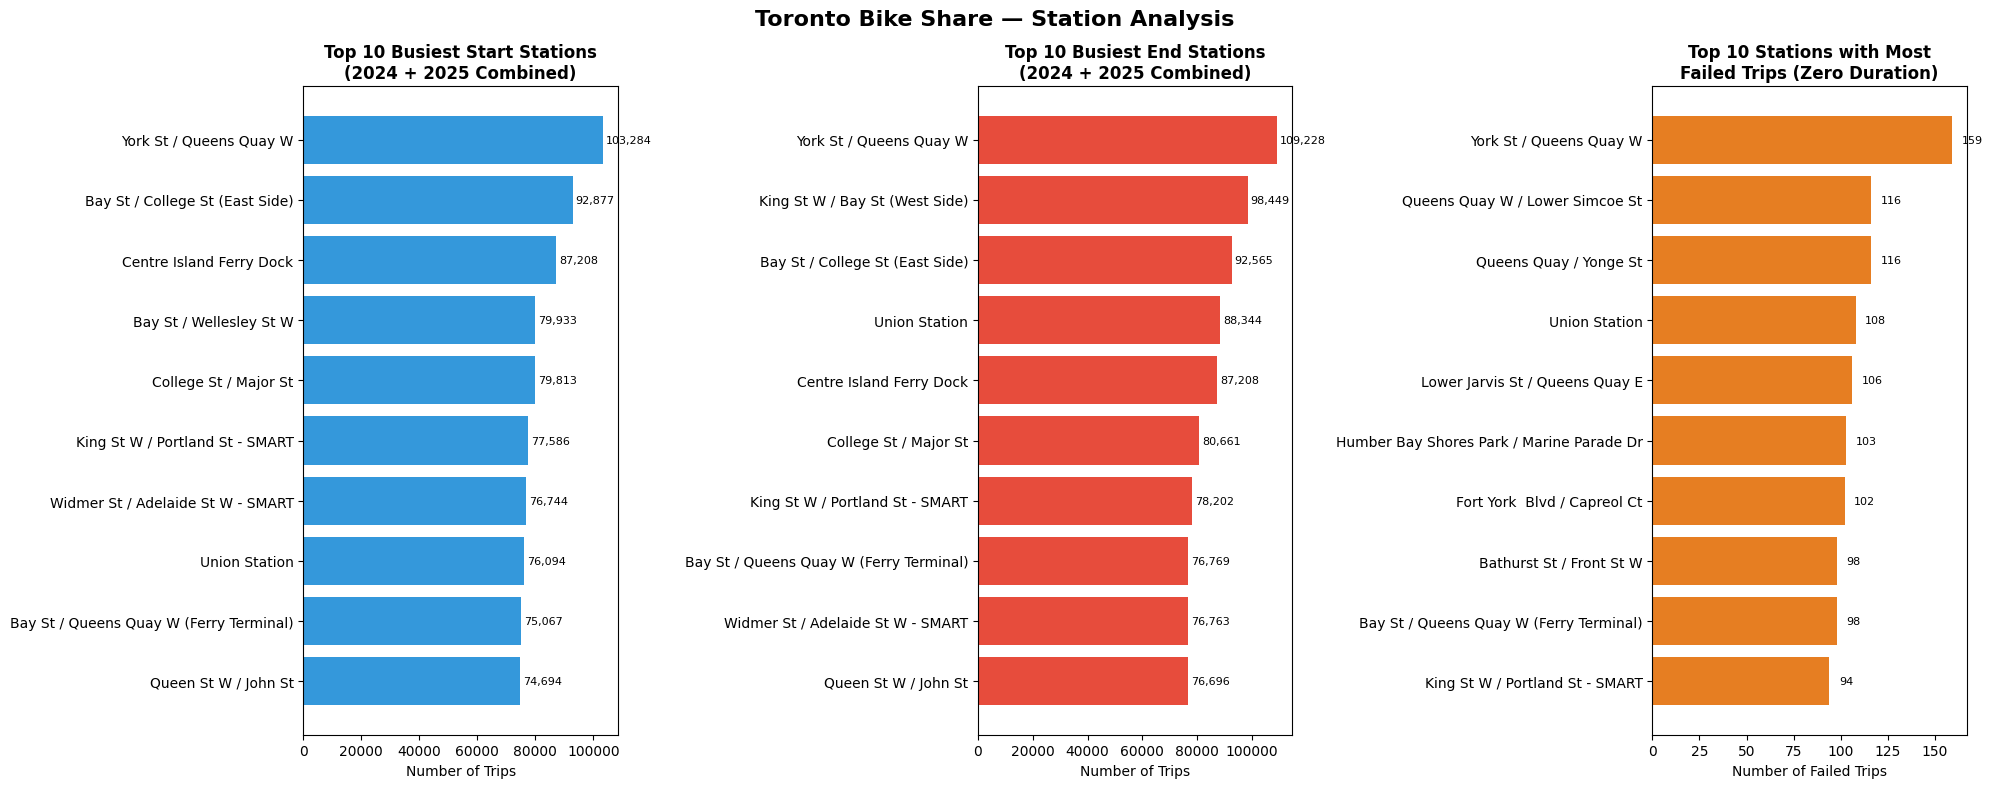

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# ── 10. Top 10 busiest start stations ─────────────────────────
top_start = df_all.groupby('Start_Station_Name').size()\
            .sort_values(ascending=False).head(10)

axes[0].barh(top_start.index, top_start.values, color='#3498db')
axes[0].set_title('Top 10 Busiest Start Stations\n(2024 + 2025 Combined)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Trips')
axes[0].invert_yaxis()
for i, val in enumerate(top_start.values):
    axes[0].text(val + 1000, i, f'{val:,.0f}',
                 va='center', fontsize=8)

# ── 11. Top 10 busiest end stations ───────────────────────────
top_end = df_all.groupby('End_Station_Name').size()\
          .sort_values(ascending=False).head(10)

axes[1].barh(top_end.index, top_end.values, color='#e74c3c')
axes[1].set_title('Top 10 Busiest End Stations\n(2024 + 2025 Combined)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Trips')
axes[1].invert_yaxis()
for i, val in enumerate(top_end.values):
    axes[1].text(val + 1000, i, f'{val:,.0f}',
                 va='center', fontsize=8)

# ── 12. Stations with most zero duration trips ─────────────────
zero_trips = df_all[df_all['Trip_Duration'] == 0]\
             .groupby('Start_Station_Name').size()\
             .sort_values(ascending=False).head(10)

axes[2].barh(zero_trips.index, zero_trips.values, color='#e67e22')
axes[2].set_title('Top 10 Stations with Most\nFailed Trips (Zero Duration)',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Failed Trips')
axes[2].invert_yaxis()
for i, val in enumerate(zero_trips.values):
    axes[2].text(val + 5, i, f'{val:,.0f}',
                 va='center', fontsize=8)

fig.suptitle('Toronto Bike Share — Station Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/station_analysis.png', dpi=150)
plt.show()

In [54]:
# add time features to df_trips as well
df_trips = df_all[df_all['Trip_Duration'] > 0].copy()

df_trips['month'] = df_trips['Start_Time'].dt.month.astype('int8')
df_trips['hour'] = df_trips['Start_Time'].dt.hour.astype('int8')
df_trips['day_of_week'] = df_trips['Start_Time'].dt.day_name().astype('category')
df_trips['season'] = df_trips['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}).astype('category')

print(df_trips.shape)
print(df_trips.columns.tolist())

(14749262, 16)
['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time', 'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name', 'Bike_Id', 'User_Type', 'Bike_Model', 'Year', 'month', 'hour', 'day_of_week', 'season']


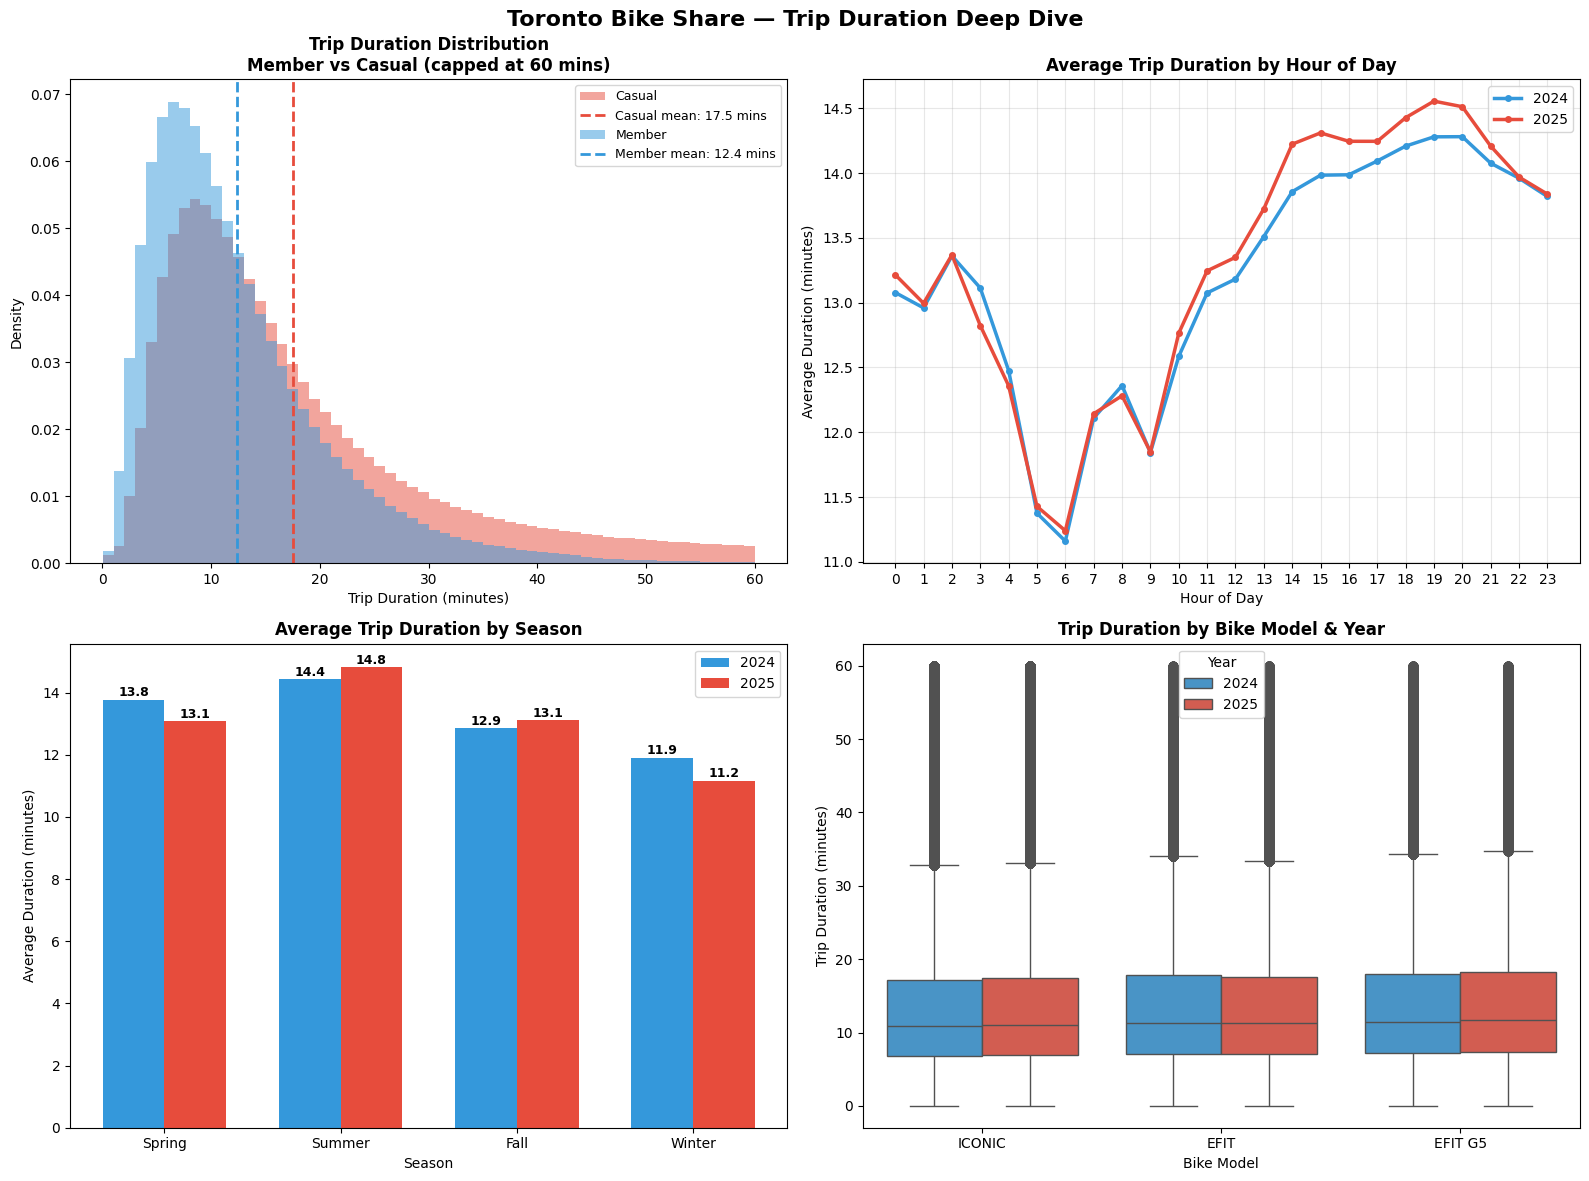

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# cap at 60 mins for readability
df_plot = df_trips[df_trips['Trip_Duration'] <= 3600].copy()
df_plot['Duration_mins'] = df_plot['Trip_Duration'] / 60

# ── 13. Trip duration distribution — Member vs Casual ──────────
for user, color in [('Casual', '#e74c3c'), ('Member', '#3498db')]:
    subset = df_plot[df_plot['User_Type'] == user]['Duration_mins']
    axes[0].hist(subset, bins=60, alpha=0.5,
                 color=color, label=user,
                 density=True)
    axes[0].axvline(subset.mean(), color=color,
                    linestyle='--', linewidth=2,
                    label=f'{user} mean: {subset.mean():.1f} mins')

axes[0].set_title('Trip Duration Distribution\nMember vs Casual (capped at 60 mins)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Trip Duration (minutes)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# ── 14. Average trip duration by hour of day ──────────────────
avg_duration_hour = df_plot.groupby(['hour', 'Year'])['Duration_mins']\
                    .mean().reset_index()

for year, color in [(2024, '#3498db'), (2025, '#e74c3c')]:
    data = avg_duration_hour[avg_duration_hour['Year'] == year]
    axes[1].plot(data['hour'], data['Duration_mins'],
                 color=color, linewidth=2.5,
                 marker='o', markersize=4,
                 label=str(year))

axes[1].set_title('Average Trip Duration by Hour of Day',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average Duration (minutes)')
axes[1].set_xticks(range(0, 24))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── 15. Average trip duration by season — 2024 vs 2025 ────────
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

avg_duration_season = df_plot.groupby(['season', 'Year'])['Duration_mins']\
                      .mean().reset_index()

x = np.arange(len(season_order))
width = 0.35

vals_2024 = [avg_duration_season[(avg_duration_season['Year']==2024) &
             (avg_duration_season['season']==s)]['Duration_mins'].values[0]
             for s in season_order]
vals_2025 = [avg_duration_season[(avg_duration_season['Year']==2025) &
             (avg_duration_season['season']==s)]['Duration_mins'].values[0]
             for s in season_order]

bars1 = axes[2].bar(x - width/2, vals_2024, width,
                    color='#3498db', label='2024')
bars2 = axes[2].bar(x + width/2, vals_2025, width,
                    color='#e74c3c', label='2025')

axes[2].set_title('Average Trip Duration by Season',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Season')
axes[2].set_ylabel('Average Duration (minutes)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(season_order)
axes[2].legend()

for bar in bars1:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}',
                 ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}',
                 ha='center', fontsize=9, fontweight='bold')

# ── 16. Trip duration by bike model ───────────────────────────
sns.boxplot(data=df_plot, x='Bike_Model', y='Duration_mins',
            hue='Year',
            palette={2024: '#3498db', 2025: '#e74c3c'},
            order=['ICONIC', 'EFIT', 'EFIT G5'],
            ax=axes[3])

axes[3].set_title('Trip Duration by Bike Model & Year',
                  fontsize=12, fontweight='bold')
axes[3].set_xlabel('Bike Model')
axes[3].set_ylabel('Trip Duration (minutes)')
axes[3].legend(title='Year')

fig.suptitle('Toronto Bike Share — Trip Duration Deep Dive',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/trip_duration_analysis.png', dpi=150)
plt.show()

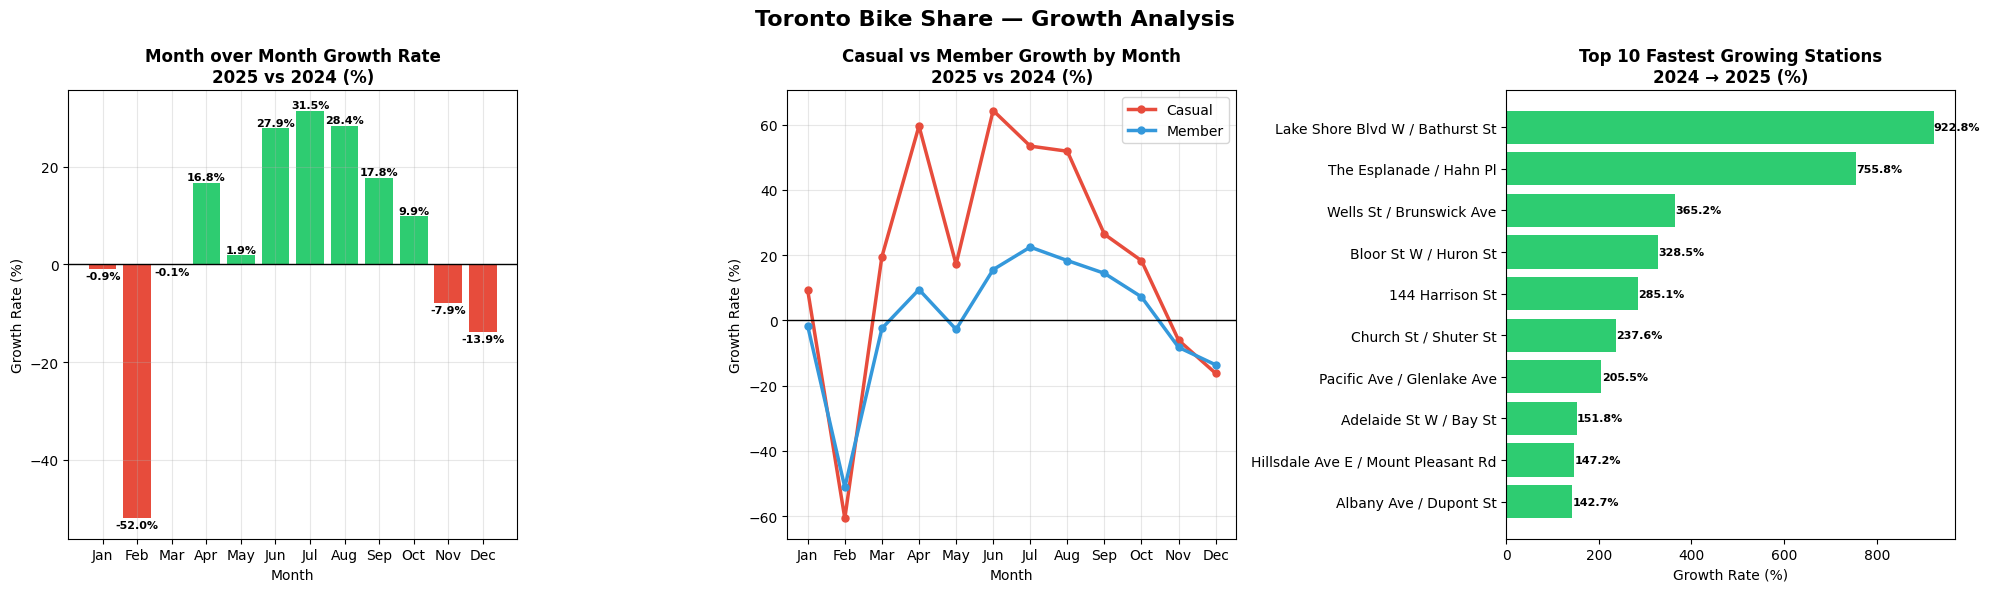

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── 17. Month over month growth rate ──────────────────────────
trips_by_month = df_all.groupby(['Year', 'month']).size().reset_index(name='trips')

trips_2024 = trips_by_month[trips_by_month['Year']==2024].set_index('month')['trips']
trips_2025 = trips_by_month[trips_by_month['Year']==2025].set_index('month')['trips']

growth_rate = ((trips_2025 - trips_2024) / trips_2024 * 100)

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in growth_rate.values]
bars = axes[0].bar(growth_rate.index, growth_rate.values, color=colors)

axes[0].axhline(y=0, color='black', linewidth=1)
axes[0].set_title('Month over Month Growth Rate\n2025 vs 2024 (%)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Growth Rate (%)')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0].grid(True, alpha=0.3)

for bar, val in zip(bars, growth_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5 if val > 0 else bar.get_height() - 2,
                 f'{val:.1f}%', ha='center',
                 fontsize=8, fontweight='bold')

# ── 18. Casual vs Member growth by month ──────────────────────
user_month = df_all.groupby(['Year', 'month', 'User_Type'])\
             .size().reset_index(name='trips')

for user, color in [('Casual', '#e74c3c'), ('Member', '#3498db')]:
    data_2024 = user_month[(user_month['Year']==2024) &
                (user_month['User_Type']==user)].set_index('month')['trips']
    data_2025 = user_month[(user_month['Year']==2025) &
                (user_month['User_Type']==user)].set_index('month')['trips']

    growth = ((data_2025 - data_2024) / data_2024 * 100)

    axes[1].plot(growth.index, growth.values,
                 color=color, linewidth=2.5,
                 marker='o', markersize=5,
                 label=user)

axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title('Casual vs Member Growth by Month\n2025 vs 2024 (%)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Growth Rate (%)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── 19. Top 10 fastest growing stations ───────────────────────
station_year = df_all.groupby(['Year', 'Start_Station_Name'])\
               .size().reset_index(name='trips')

trips_2024_st = station_year[station_year['Year']==2024]\
                .set_index('Start_Station_Name')['trips']
trips_2025_st = station_year[station_year['Year']==2025]\
                .set_index('Start_Station_Name')['trips']

# only keep stations present in both years
common = trips_2024_st.index.intersection(trips_2025_st.index)
growth_stations = ((trips_2025_st[common] - trips_2024_st[common]) /
                    trips_2024_st[common] * 100)

# filter stations with at least 1000 trips in 2024 to avoid noise
min_trips = trips_2024_st[common] >= 1000
growth_stations = growth_stations[min_trips]\
                  .sort_values(ascending=False).head(10)

axes[2].barh(growth_stations.index, growth_stations.values,
             color='#2ecc71')
axes[2].set_title('Top 10 Fastest Growing Stations\n2024 → 2025 (%)',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Growth Rate (%)')
axes[2].invert_yaxis()

for i, val in enumerate(growth_stations.values):
    axes[2].text(val + 0.5, i, f'{val:.1f}%',
                 va='center', fontsize=8, fontweight='bold')

fig.suptitle('Toronto Bike Share — Growth Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/growth_analysis.png', dpi=150)
plt.show()

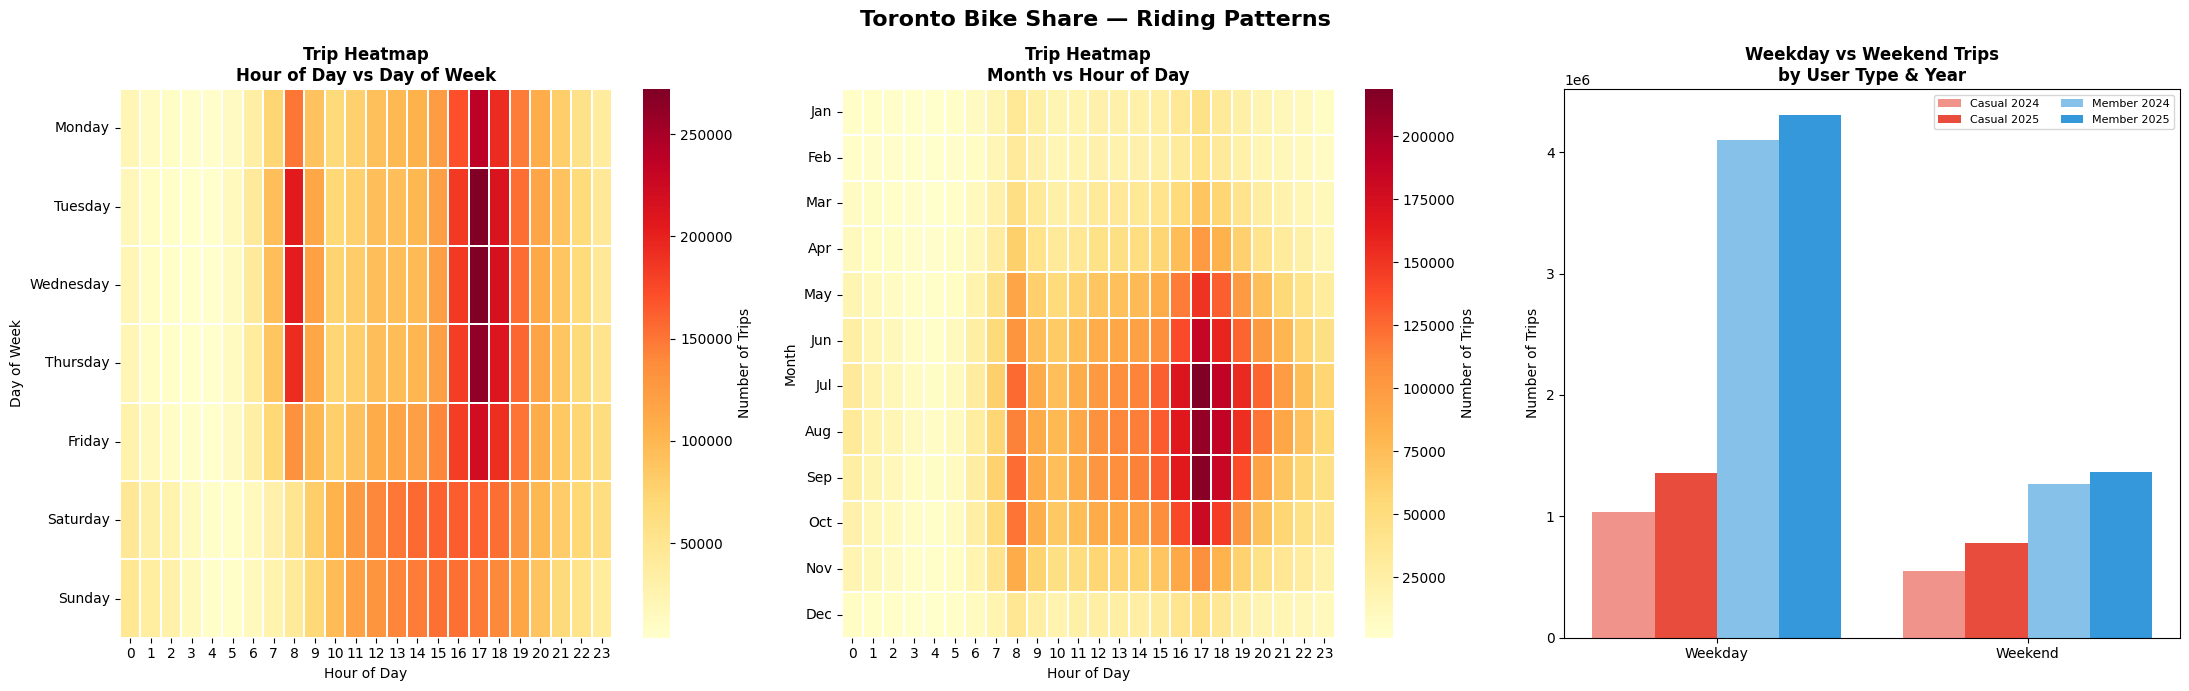

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── 20. Heatmap — hour of day vs day of week ──────────────────
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = df_all.groupby(['day_of_week', 'hour'])\
               .size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(day_order)

sns.heatmap(heatmap_data, cmap='YlOrRd',
            ax=axes[0], fmt=',',
            linewidths=0.3,
            cbar_kws={'label': 'Number of Trips'})

axes[0].set_title('Trip Heatmap\nHour of Day vs Day of Week',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Day of Week')
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=0)

# ── 21. Heatmap — month vs hour of day ────────────────────────
heatmap_month = df_all.groupby(['month', 'hour'])\
                .size().unstack(fill_value=0)

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

sns.heatmap(heatmap_month, cmap='YlOrRd',
            ax=axes[1], linewidths=0.3,
            yticklabels=month_labels,
            cbar_kws={'label': 'Number of Trips'})

axes[1].set_title('Trip Heatmap\nMonth vs Hour of Day',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Month')
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)

# ── 22. Weekend vs Weekday by user type ───────────────────────
df_all['is_weekend'] = df_all['day_of_week'].isin(
    ['Saturday', 'Sunday']).map({True: 'Weekend', False: 'Weekday'})

weekend_user = df_all.groupby(['is_weekend', 'User_Type', 'Year'])\
               .size().reset_index(name='trips')

x = np.arange(2)
width = 0.2

for idx, (user, color) in enumerate([('Casual', '#e74c3c'),
                                      ('Member', '#3498db')]):
    for jdx, (year, alpha) in enumerate([(2024, 0.6), (2025, 1.0)]):
        data = weekend_user[(weekend_user['User_Type']==user) &
                            (weekend_user['Year']==year)]
        vals = [data[data['is_weekend']==w]['trips'].values[0]
                for w in ['Weekday', 'Weekend']]
        offset = (idx * 2 + jdx) * width - 1.5 * width
        bars = axes[2].bar(x + offset, vals, width,
                           color=color, alpha=alpha,
                           label=f'{user} {year}')

axes[2].set_title('Weekday vs Weekend Trips\nby User Type & Year',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('Number of Trips')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Weekday', 'Weekend'])
axes[2].legend(fontsize=8, ncol=2)

fig.suptitle('Toronto Bike Share — Riding Patterns',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/riding_patterns.png', dpi=150)
plt.show()

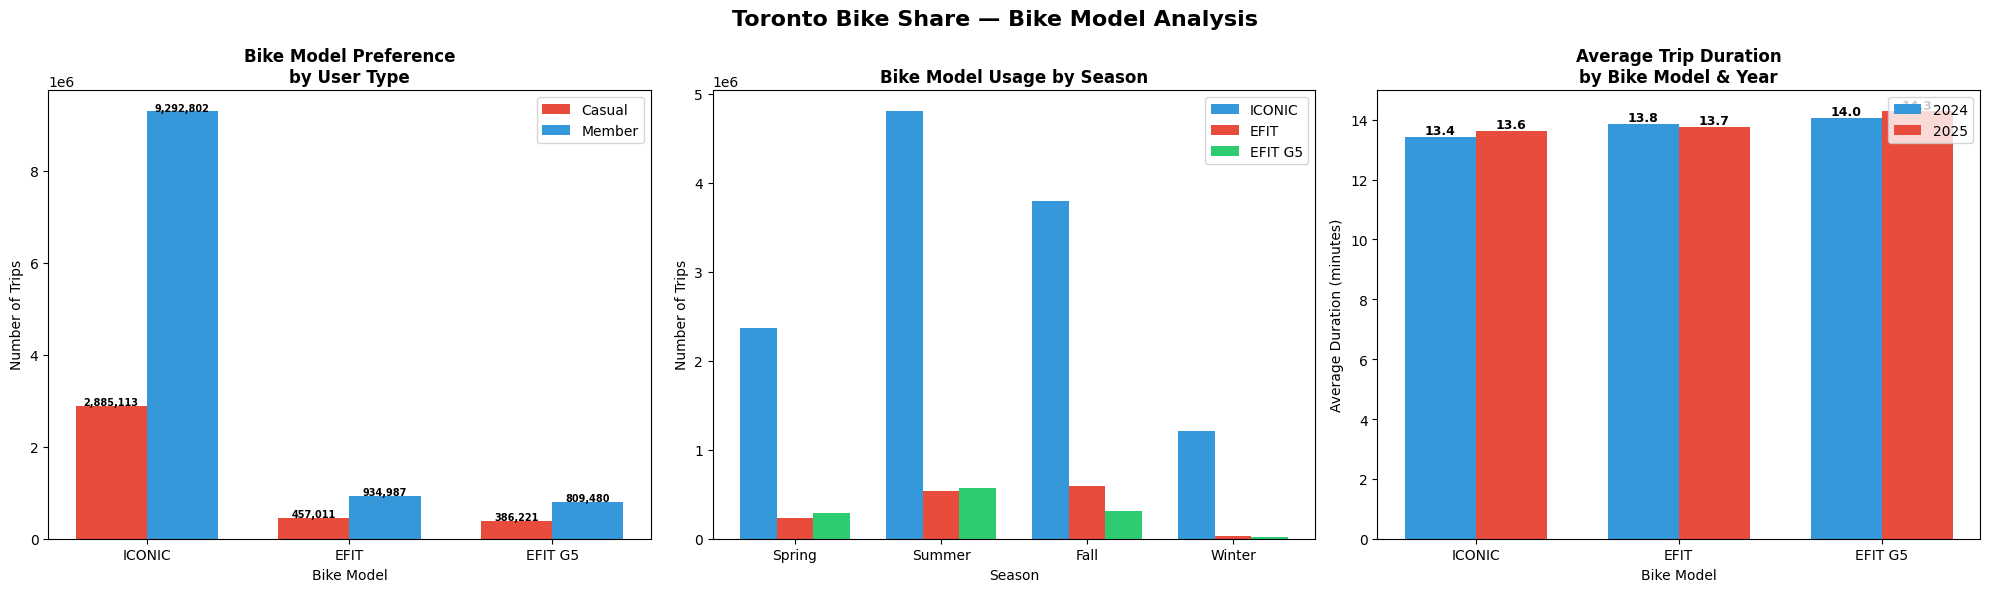

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── 24. Bike model preference by user type ────────────────────
bike_user = df_all.groupby(['Bike_Model', 'User_Type'])\
            .size().reset_index(name='trips')

models = ['ICONIC', 'EFIT', 'EFIT G5']
x = np.arange(len(models))
width = 0.35

casual_vals = [bike_user[(bike_user['Bike_Model']==m) &
               (bike_user['User_Type']=='Casual')]['trips'].values[0]
               for m in models]
member_vals = [bike_user[(bike_user['Bike_Model']==m) &
               (bike_user['User_Type']=='Member')]['trips'].values[0]
               for m in models]

bars1 = axes[0].bar(x - width/2, casual_vals, width,
                    color='#e74c3c', label='Casual')
bars2 = axes[0].bar(x + width/2, member_vals, width,
                    color='#3498db', label='Member')

axes[0].set_title('Bike Model Preference\nby User Type',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Bike Model')
axes[0].set_ylabel('Number of Trips')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20000,
                 f'{bar.get_height():,.0f}',
                 ha='center', fontsize=7, fontweight='bold')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20000,
                 f'{bar.get_height():,.0f}',
                 ha='center', fontsize=7, fontweight='bold')

# ── 25. Bike model usage by season ────────────────────────────
bike_season = df_all.groupby(['season', 'Bike_Model'])\
              .size().reset_index(name='trips')

season_order = ['Spring', 'Summer', 'Fall', 'Winter']
x = np.arange(len(season_order))
width = 0.25

colors = {'ICONIC': '#3498db', 'EFIT': '#e74c3c', 'EFIT G5': '#2ecc71'}

for idx, model in enumerate(['ICONIC', 'EFIT', 'EFIT G5']):
    vals = [bike_season[(bike_season['season']==s) &
            (bike_season['Bike_Model']==model)]['trips'].values[0]
            for s in season_order]
    offset = (idx - 1) * width
    axes[1].bar(x + offset, vals, width,
                color=colors[model], label=model)

axes[1].set_title('Bike Model Usage by Season',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Number of Trips')
axes[1].set_xticks(x)
axes[1].set_xticklabels(season_order)
axes[1].legend()

# ── 26. Bike model average trip duration ──────────────────────
df_plot = df_trips[df_trips['Trip_Duration'] <= 3600].copy()
df_plot['Duration_mins'] = df_plot['Trip_Duration'] / 60

avg_duration_model = df_plot.groupby(['Bike_Model', 'Year'])\
                    ['Duration_mins'].mean().reset_index()

x = np.arange(len(models))
width = 0.35

vals_2024 = [avg_duration_model[(avg_duration_model['Bike_Model']==m) &
             (avg_duration_model['Year']==2024)]['Duration_mins'].values[0]
             for m in models]
vals_2025 = [avg_duration_model[(avg_duration_model['Bike_Model']==m) &
             (avg_duration_model['Year']==2025)]['Duration_mins'].values[0]
             for m in models]

bars1 = axes[2].bar(x - width/2, vals_2024, width,
                    color='#3498db', label='2024')
bars2 = axes[2].bar(x + width/2, vals_2025, width,
                    color='#e74c3c', label='2025')

axes[2].set_title('Average Trip Duration\nby Bike Model & Year',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Bike Model')
axes[2].set_ylabel('Average Duration (minutes)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models)
axes[2].legend()

for bar in bars1:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}',
                 ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}',
                 ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Toronto Bike Share — Bike Model Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/bike_model_analysis.png', dpi=150)
plt.show()

New stations added in 2025: 237


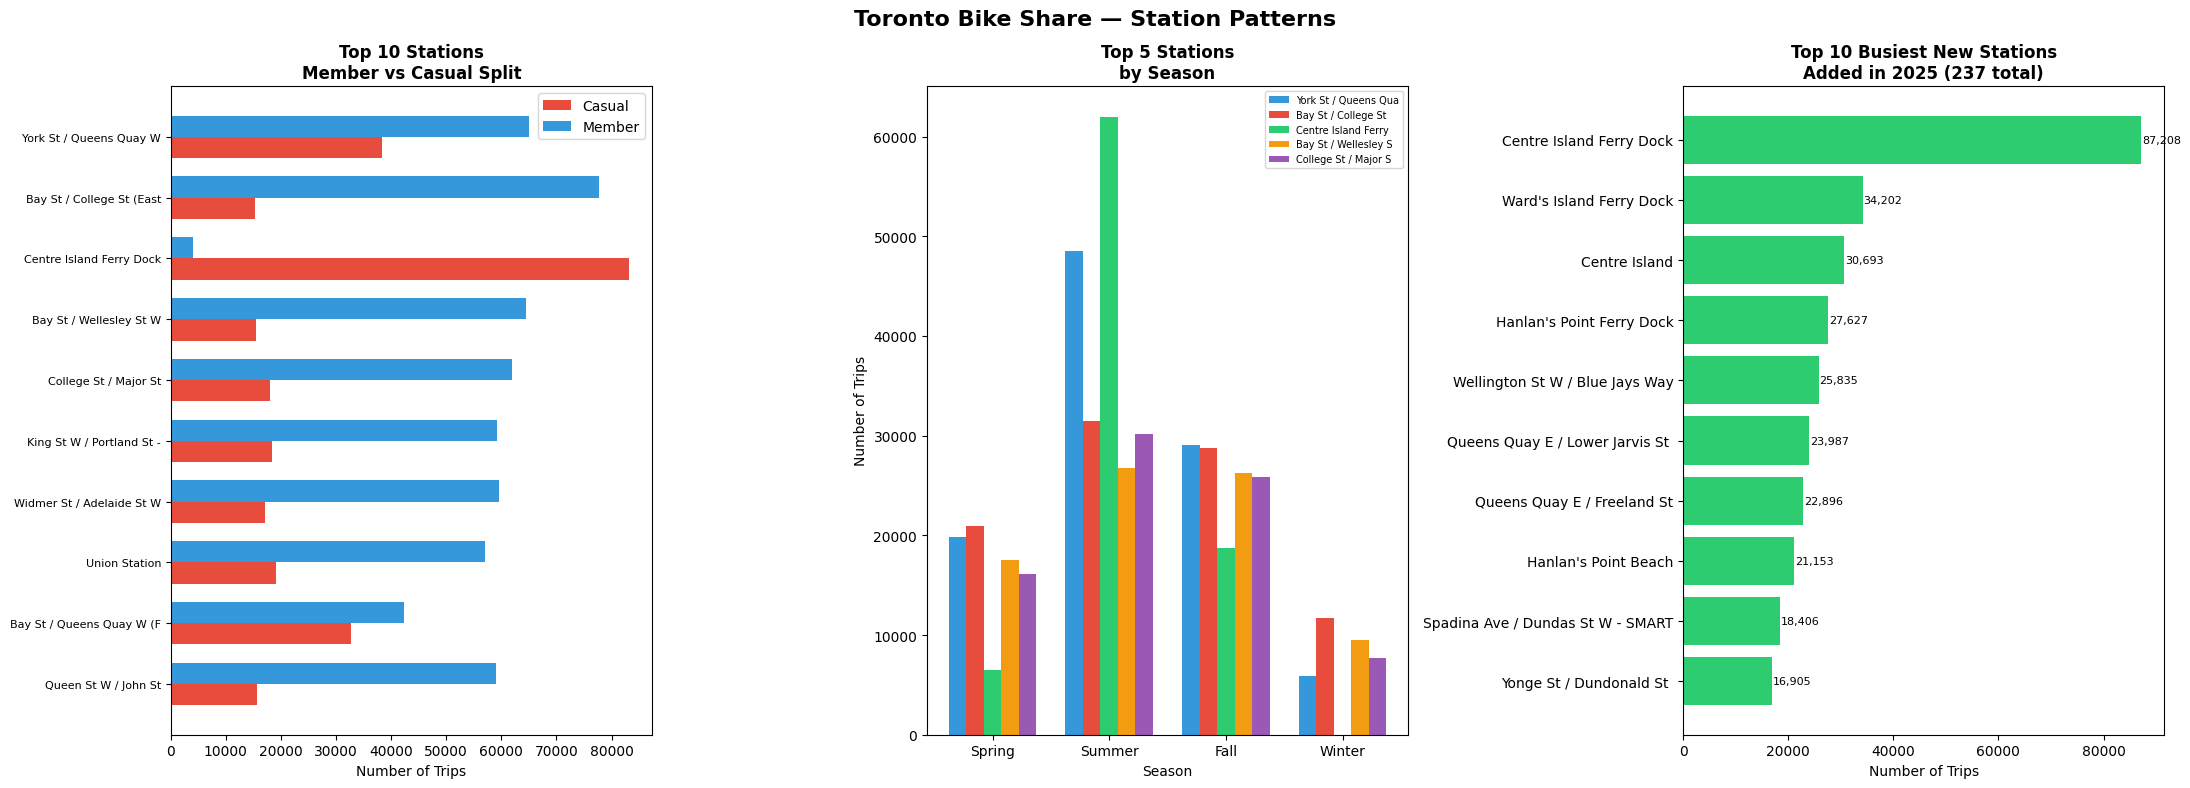

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# ── 27. Top 10 stations — Member vs Casual split ──────────────
top10_stations = df_all.groupby('Start_Station_Name')\
                 .size().sort_values(ascending=False)\
                 .head(10).index.tolist()

station_user = df_all[df_all['Start_Station_Name'].isin(top10_stations)]\
               .groupby(['Start_Station_Name', 'User_Type'])\
               .size().reset_index(name='trips')

casual_vals = [station_user[(station_user['Start_Station_Name']==s) &
               (station_user['User_Type']=='Casual')]['trips'].values[0]
               for s in top10_stations]
member_vals = [station_user[(station_user['Start_Station_Name']==s) &
               (station_user['User_Type']=='Member')]['trips'].values[0]
               for s in top10_stations]

x = np.arange(len(top10_stations))
width = 0.35

axes[0].barh(x + width/2, casual_vals, width,
             color='#e74c3c', label='Casual')
axes[0].barh(x - width/2, member_vals, width,
             color='#3498db', label='Member')

axes[0].set_title('Top 10 Stations\nMember vs Casual Split',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Trips')
axes[0].set_yticks(x)
axes[0].set_yticklabels([s[:25] for s in top10_stations], fontsize=8)
axes[0].invert_yaxis()
axes[0].legend()

# ── 28. Busiest stations by season ────────────────────────────
top5_stations = df_all.groupby('Start_Station_Name')\
                .size().sort_values(ascending=False)\
                .head(5).index.tolist()

season_station = df_all[df_all['Start_Station_Name'].isin(top5_stations)]\
                 .groupby(['season', 'Start_Station_Name'])\
                 .size().reset_index(name='trips')

season_order = ['Spring', 'Summer', 'Fall', 'Winter']
x = np.arange(len(season_order))
width = 0.15

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, (station, color) in enumerate(zip(top5_stations, colors)):
    vals = [season_station[(season_station['season']==s) &
            (season_station['Start_Station_Name']==station)]['trips'].values[0]
            for s in season_order]
    offset = (idx - 2) * width
    axes[1].bar(x + offset, vals, width,
                color=color,
                label=station[:20])

axes[1].set_title('Top 5 Stations\nby Season',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Number of Trips')
axes[1].set_xticks(x)
axes[1].set_xticklabels(season_order)
axes[1].legend(fontsize=7, loc='upper right')

# ── 29. Stations unique to 2025 — new stations ────────────────
stations_2024 = set(df_all[df_all['Year']==2024]['Start_Station_Name'].unique())
stations_2025 = set(df_all[df_all['Year']==2025]['Start_Station_Name'].unique())

new_stations_2025 = stations_2025 - stations_2024
print(f"New stations added in 2025: {len(new_stations_2025)}")

new_station_trips = df_all[(df_all['Year']==2025) &
                    (df_all['Start_Station_Name'].isin(new_stations_2025))]\
                    .groupby('Start_Station_Name').size()\
                    .sort_values(ascending=False).head(10)

axes[2].barh(new_station_trips.index,
             new_station_trips.values,
             color='#2ecc71')
axes[2].set_title(f'Top 10 Busiest New Stations\nAdded in 2025 ({len(new_stations_2025)} total)',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Trips')
axes[2].invert_yaxis()

for i, val in enumerate(new_station_trips.values):
    axes[2].text(val + 100, i, f'{val:,.0f}',
                 va='center', fontsize=8)

fig.suptitle('Toronto Bike Share — Station Patterns',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/station_patterns.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_1411/394935431.py:204: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_1411/394935431.py:204: UserWarning: Glyph 128690 (\N{BICYCLE}) missing from current font.
  plt.tight_layout()
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_1411/394935431.py:204: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from current font.
  plt.tight_layout()
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_1411/394935431.py:204: UserWarning: Glyph 127965 (\N{DESERT ISLAND}) missing from current font.
  plt.tight_layout()
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_1411/394935431.py:204: UserWarning: Glyph 128340 (\N{CLOCK FACE FIVE OCLOCK}) missing from current font.
  plt.tight_layout()
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_1411/394935431.py:204: UserWarning: Glyph 12826

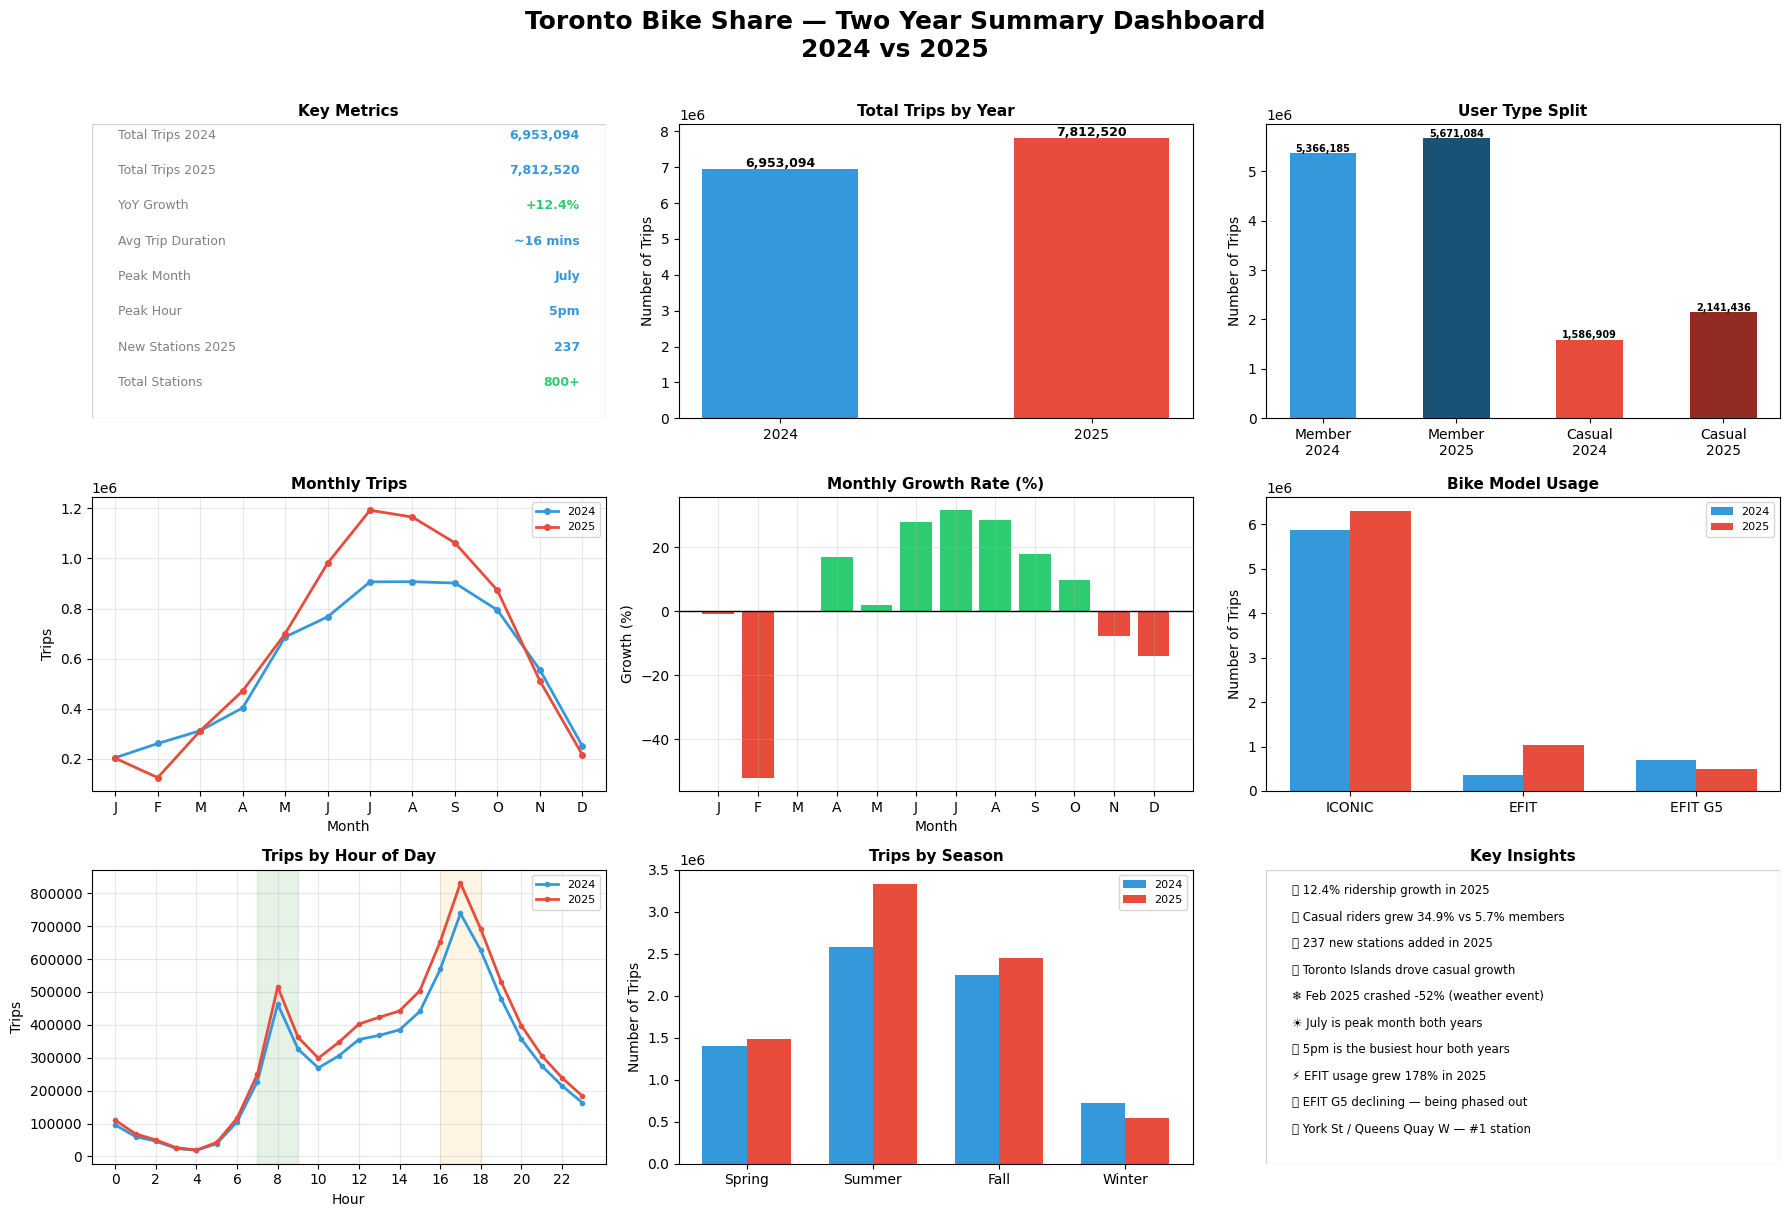

In [60]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Toronto Bike Share — Two Year Summary Dashboard\n2024 vs 2025',
             fontsize=18, fontweight='bold', y=1.01)

# ── Panel 1 — Key metrics ──────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
ax1.axis('off')

metrics = [
    ('Total Trips 2024', '6,953,094'),
    ('Total Trips 2025', '7,812,520'),
    ('YoY Growth', '+12.4%'),
    ('Avg Trip Duration', '~16 mins'),
    ('Peak Month', 'July'),
    ('Peak Hour', '5pm'),
    ('New Stations 2025', '237'),
    ('Total Stations', '800+'),
]

for i, (label, value) in enumerate(metrics):
    color = '#2ecc71' if '+' in value else '#3498db'
    ax1.text(0.05, 0.95 - i * 0.12, label,
             fontsize=9, color='gray',
             transform=ax1.transAxes)
    ax1.text(0.95, 0.95 - i * 0.12, value,
             fontsize=9, fontweight='bold',
             color=color, ha='right',
             transform=ax1.transAxes)

ax1.set_title('Key Metrics', fontsize=11, fontweight='bold')
ax1.add_patch(plt.Rectangle((0, 0), 1, 1,
              fill=False, edgecolor='lightgray',
              transform=ax1.transAxes))

# ── Panel 2 — Total trips by year ─────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)

bars = ax2.bar(['2024', '2025'], [6953094, 7812520],
               color=['#3498db', '#e74c3c'], width=0.5)
ax2.set_title('Total Trips by Year', fontsize=11, fontweight='bold')
ax2.set_ylabel('Number of Trips')
for bar, val in zip(bars, [6953094, 7812520]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50000,
             f'{val:,.0f}', ha='center',
             fontsize=9, fontweight='bold')

# ── Panel 3 — User type split ─────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)

categories = ['Member\n2024', 'Member\n2025', 'Casual\n2024', 'Casual\n2025']
values = [5366185, 5671084, 1586909, 2141436]
colors = ['#3498db', '#1a5276', '#e74c3c', '#922b21']

bars = ax3.bar(categories, values, color=colors, width=0.5)
ax3.set_title('User Type Split', fontsize=11, fontweight='bold')
ax3.set_ylabel('Number of Trips')
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 30000,
             f'{val:,.0f}', ha='center',
             fontsize=7, fontweight='bold')

# ── Panel 4 — Monthly trips both years ────────────────────────
ax4 = fig.add_subplot(3, 3, 4)

trips_by_month = df_all.groupby(['Year', 'month']).size().reset_index(name='trips')

for year, color in [(2024, '#3498db'), (2025, '#e74c3c')]:
    data = trips_by_month[trips_by_month['Year'] == year]
    ax4.plot(data['month'], data['trips'],
             color=color, linewidth=2,
             marker='o', markersize=4,
             label=str(year))

ax4.set_title('Monthly Trips', fontsize=11, fontweight='bold')
ax4.set_xlabel('Month')
ax4.set_ylabel('Trips')
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(['J','F','M','A','M','J',
                      'J','A','S','O','N','D'])
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# ── Panel 5 — Growth rate by month ────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)

trips_2024 = trips_by_month[trips_by_month['Year']==2024]\
             .set_index('month')['trips']
trips_2025 = trips_by_month[trips_by_month['Year']==2025]\
             .set_index('month')['trips']
growth = ((trips_2025 - trips_2024) / trips_2024 * 100)

colors_growth = ['#2ecc71' if v > 0 else '#e74c3c'
                 for v in growth.values]
ax5.bar(growth.index, growth.values, color=colors_growth)
ax5.axhline(y=0, color='black', linewidth=1)
ax5.set_title('Monthly Growth Rate (%)', fontsize=11, fontweight='bold')
ax5.set_xlabel('Month')
ax5.set_ylabel('Growth (%)')
ax5.set_xticks(range(1, 13))
ax5.set_xticklabels(['J','F','M','A','M','J',
                      'J','A','S','O','N','D'])
ax5.grid(True, alpha=0.3)

# ── Panel 6 — Bike model usage ────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)

bike_year = df_all.groupby(['Year', 'Bike_Model'])\
            .size().reset_index(name='trips')
models = ['ICONIC', 'EFIT', 'EFIT G5']
x = np.arange(len(models))
width = 0.35

vals_2024 = [bike_year[(bike_year['Year']==2024) &
             (bike_year['Bike_Model']==m)]['trips'].values[0]
             for m in models]
vals_2025 = [bike_year[(bike_year['Year']==2025) &
             (bike_year['Bike_Model']==m)]['trips'].values[0]
             for m in models]

ax6.bar(x - width/2, vals_2024, width, color='#3498db', label='2024')
ax6.bar(x + width/2, vals_2025, width, color='#e74c3c', label='2025')
ax6.set_title('Bike Model Usage', fontsize=11, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(models)
ax6.set_ylabel('Number of Trips')
ax6.legend(fontsize=8)

# ── Panel 7 — Hour of day pattern ─────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)

trips_by_hour = df_all.groupby(['hour', 'Year'])\
                .size().reset_index(name='trips')

for year, color in [(2024, '#3498db'), (2025, '#e74c3c')]:
    data = trips_by_hour[trips_by_hour['Year'] == year]
    ax7.plot(data['hour'], data['trips'],
             color=color, linewidth=2,
             marker='o', markersize=3,
             label=str(year))

ax7.set_title('Trips by Hour of Day', fontsize=11, fontweight='bold')
ax7.set_xlabel('Hour')
ax7.set_ylabel('Trips')
ax7.set_xticks(range(0, 24, 2))
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.3)
ax7.axvspan(7, 9, alpha=0.1, color='green')
ax7.axvspan(16, 18, alpha=0.1, color='orange')

# ── Panel 8 — Season trips ────────────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)

season_order = ['Spring', 'Summer', 'Fall', 'Winter']
trips_by_season = df_all.groupby(['season', 'Year'])\
                  .size().reset_index(name='trips')

x = np.arange(len(season_order))
width = 0.35

vals_2024 = [trips_by_season[(trips_by_season['Year']==2024) &
             (trips_by_season['season']==s)]['trips'].values[0]
             for s in season_order]
vals_2025 = [trips_by_season[(trips_by_season['Year']==2025) &
             (trips_by_season['season']==s)]['trips'].values[0]
             for s in season_order]

ax8.bar(x - width/2, vals_2024, width, color='#3498db', label='2024')
ax8.bar(x + width/2, vals_2025, width, color='#e74c3c', label='2025')
ax8.set_title('Trips by Season', fontsize=11, fontweight='bold')
ax8.set_xticks(x)
ax8.set_xticklabels(season_order)
ax8.set_ylabel('Number of Trips')
ax8.legend(fontsize=8)

# ── Panel 9 — Key insights text ───────────────────────────────
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')

insights = [
    '📈 12.4% ridership growth in 2025',
    '🚲 Casual riders grew 34.9% vs 5.7% members',
    '📍 237 new stations added in 2025',
    '🏝️ Toronto Islands drove casual growth',
    '❄️ Feb 2025 crashed -52% (weather event)',
    '☀️ July is peak month both years',
    '🕔 5pm is the busiest hour both years',
    '⚡ EFIT usage grew 178% in 2025',
    '🔄 EFIT G5 declining — being phased out',
    '🗺️ York St / Queens Quay W — #1 station',
]

ax9.set_title('Key Insights', fontsize=11, fontweight='bold')
for i, insight in enumerate(insights):
    ax9.text(0.05, 0.95 - i * 0.09, insight,
             fontsize=8.5, transform=ax9.transAxes,
             va='top')

ax9.add_patch(plt.Rectangle((0, 0), 1, 1,
              fill=False, edgecolor='lightgray',
              transform=ax9.transAxes))

plt.tight_layout()
plt.savefig('visualizations/summary_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()